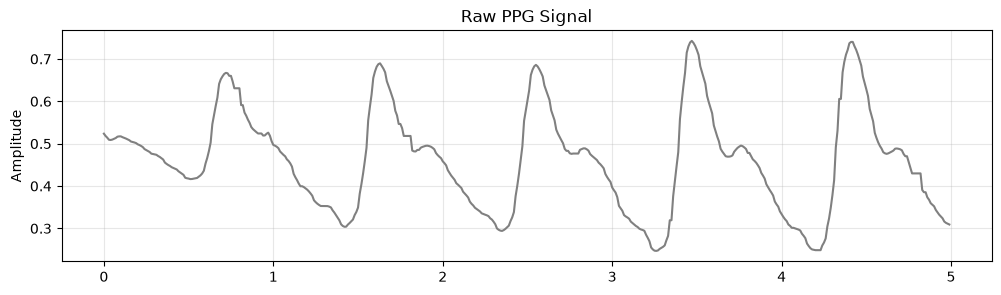

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

file_path = "../data/raw/uq_vital_signs/uqvitalsignsdata/case01/fulldata/uq_vsd_case01_fulldata_01.csv"
df = pd.read_csv(file_path, on_bad_lines='skip', low_memory=False)

# Force the mislabeled 'ECG' column to numeric
df['ECG'] = pd.to_numeric(df['ECG'], errors='coerce')

# Start 50 seconds in (index 5000) to bypass initialization artifacts
start_idx = 5000
window_size = 500 # 5 seconds at 100 Hz

# Extract the mislabeled PPG signal
raw_ppg_signal = df['ECG'].iloc[start_idx : start_idx + window_size].values
time_axis = np.arange(window_size) / 100.0


# Plot 1: Raw mislabeled signal
plt.figure(figsize=(12, 3))
plt.plot(time_axis, raw_ppg_signal, color='gray')
plt.title("Raw PPG Signal")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

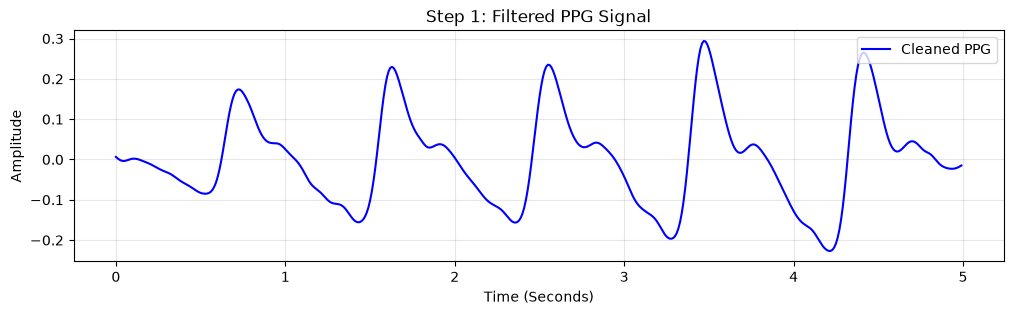

In [15]:
# 1. Clean the signal
ppg_cleaned = nk.ppg_clean(raw_ppg_signal, sampling_rate=100)

# Plot just the cleaned signal
plt.figure(figsize=(12, 3))
plt.plot(time_axis, ppg_cleaned, color='blue', label="Cleaned PPG")
plt.title("Step 1: Filtered PPG Signal")
plt.ylabel("Amplitude")
plt.xlabel("Time (Seconds)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

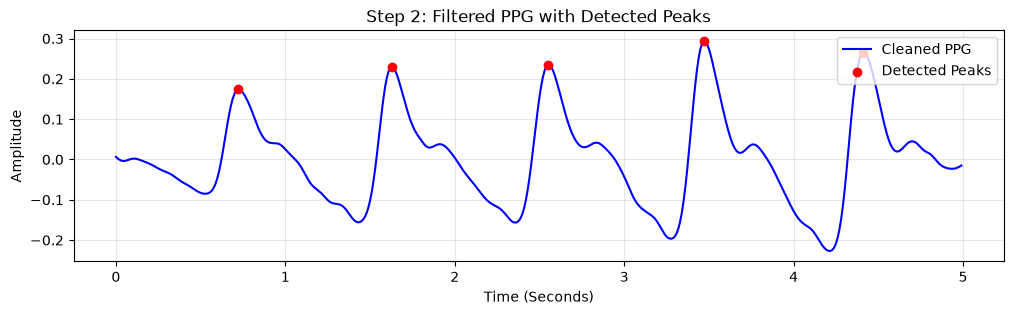

In [16]:
# 2. Find peaks (for SBP features)
info = nk.ppg_findpeaks(ppg_cleaned, sampling_rate=100)
peaks = info["PPG_Peaks"]

# Plot the cleaned signal with the red peak markers
plt.figure(figsize=(12, 3))
plt.plot(time_axis, ppg_cleaned, color='blue', label="Cleaned PPG")
plt.scatter(time_axis[peaks], ppg_cleaned[peaks], color='red', label="Detected Peaks", zorder=3)
plt.title("Step 2: Filtered PPG with Detected Peaks")
plt.ylabel("Amplitude")
plt.xlabel("Time (Seconds)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

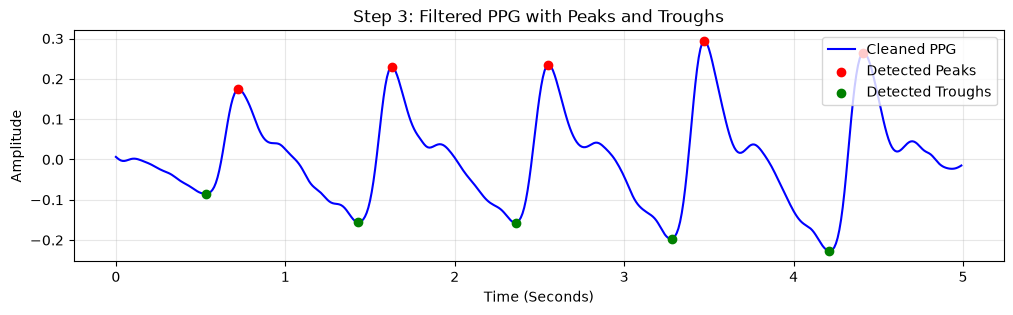

Algorithm successfully detected 5 peaks and 5 troughs.


In [17]:
# 3. Find troughs (for DBP features) by inverting the signal
inverted_ppg = ppg_cleaned * -1
trough_info = nk.ppg_findpeaks(inverted_ppg, sampling_rate=100)
troughs = trough_info["PPG_Peaks"]

# Plot the fully annotated signal with both peaks and troughs
plt.figure(figsize=(12, 3))
plt.plot(time_axis, ppg_cleaned, color='blue', label="Cleaned PPG")
plt.scatter(time_axis[peaks], ppg_cleaned[peaks], color='red', label="Detected Peaks", zorder=3)
plt.scatter(time_axis[troughs], ppg_cleaned[troughs], color='green', label="Detected Troughs", zorder=3)
plt.title("Step 3: Filtered PPG with Peaks and Troughs")
plt.ylabel("Amplitude")
plt.xlabel("Time (Seconds)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Algorithm successfully detected {len(peaks)} peaks and {len(troughs)} troughs.")

In [18]:

# 1. Get the exact time (in seconds) of every red dot (peak)
peak_times = time_axis[peaks]

# 2. Calculate the time difference between consecutive peaks
# np.diff subtracts peak 1 from peak 2, peak 2 from peak 3, etc.
ibi_seconds = np.diff(peak_times)

# 3. Convert to milliseconds (HRV algorithms expect milliseconds)
ibi_ms = ibi_seconds * 1000

# 4. Create a structured table to view the extracted data
ibi_table = pd.DataFrame({
    "Peak 1 Time (s)": np.round(peak_times[:-1], 2),
    "Peak 2 Time (s)": np.round(peak_times[1:], 2),
    "IBI (milliseconds)": np.round(ibi_ms, 1)
})

# display() is Jupyter's built-in function to render beautiful data tables
display(ibi_table.head(10))

# Calculate the average Heart Rate from these IBIs
average_ibi_sec = np.mean(ibi_seconds)
bpm = 60 / average_ibi_sec
print(f"\nAverage Heart Rate for this window: {bpm:.0f} Beats Per Minute")

,Peak 1 Time (s),Peak 2 Time (s),IBI (milliseconds)
0,0.72,1.63,910.0
1,1.63,2.55,920.0
2,2.55,3.47,920.0
3,3.47,4.41,940.0



Average Heart Rate for this window: 65 Beats Per Minute


In [19]:
import neurokit2 as nk
import pandas as pd

# 1. Calculate the full suite of HRV/PRV dynamics from the peaks
# neurokit2 handles the time-domain, frequency-domain, and non-linear math automatically
prv_metrics = nk.hrv(peaks, sampling_rate=100, show=False)

# 2. Isolate the exact 7 features specified in the paper's final calibration-free model
paper_features = [
    'HRV_SDNN',         # SDNN: Standard deviation of IBIs
    'HRV_HTI',          # PRVTi: HRV triangular index
    'HRV_TINN',         # TINN: Baseline width of the IBI histogram
    'HRV_LF',           # LF: Low-frequency power
    'HRV_HF',           # HF: High-frequency power
    'HRV_DFA_alpha1',   # a1: Detrended fluctuation analysis (short-term)
    'HRV_DFA_alpha2'    # a2: Detrended fluctuation analysis (long-term)
]

# Extract just the columns we need
dynamics_features = prv_metrics[paper_features].copy()

# Rename them to match the paper's exact terminology for clarity
dynamics_features.columns = ['SDNN', 'PRVTi', 'TINN', 'LF', 'HF', 'a1', 'a2']

# Display the extracted feature vector
display(dynamics_features.T)

/home/amal-shaheen/Documents/Main Project/cuffless-bp-estimation/venv/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
/home/amal-shaheen/Documents/Main Project/cuffless-bp-estimation/venv/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/home/amal-shaheen/Documents/Main Project/cuffless-bp-estimation/venv/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid value encountered in multiply
  sets = (np.nansum(np.abs(np.diff(sig_values)), axis=1) * normalization) / k


,0
SDNN,12.583057
PRVTi,2.000000
TINN,0.000000
LF,NaN
HF,NaN
a1,NaN
a2,NaN


In [20]:
import numpy as np
import pandas as pd

# Extract 7 morphology features using the mPTP method across all pulses
morphology_records = []

# Troughs mark the start/end of each individual pulse wave
for i in range(len(troughs) - 1):
    t_start = troughs[i]
    t_end = troughs[i + 1]
    
    # Locate the systolic peak between these two troughs
    matching_peaks = [p for p in peaks if t_start < p < t_end]
    if len(matching_peaks) != 1:
        continue
    p_curr = matching_peaks[0]
    
    segment = ppg_cleaned[t_start:t_end]
    local_p = p_curr - t_start
    
    y_min = np.min(segment)
    y_max = segment[local_p]
    amp = y_max - y_min
    if amp <= 0:
        continue
        
    # Amplitude percentage levels
    h10 = y_min + 0.10 * amp
    h25 = y_min + 0.25 * amp
    h33 = y_min + 0.33 * amp
    h75 = y_min + 0.75 * amp
    
    def find_crossings(sig, p_idx, level):
        up = np.where(sig[:p_idx] <= level)[0]
        down = np.where(sig[p_idx:] <= level)[0]
        up_idx = up[-1] if len(up) > 0 else 0
        down_idx = p_idx + down[0] if len(down) > 0 else len(sig) - 1
        return up_idx, down_idx

    u10, d10 = find_crossings(segment, local_p, h10)
    u25, d25 = find_crossings(segment, local_p, h25)
    u33, d33 = find_crossings(segment, local_p, h33)
    u75, d75 = find_crossings(segment, local_p, h75)
    
    # 7 morphology metrics in samples (fs = 100 Hz, so 1 sample = 10 ms)
    cardiac_period = len(segment)
    diastolic_time = len(segment) - local_p
    dias_w_25 = d25 - local_p
    dias_w_75 = d75 - local_p
    sum_w_33 = d33 - u33
    sum_w_75 = d75 - u75
    
    sys_w_10 = max(local_p - u10, 1)
    dias_w_10 = max(d10 - local_p, 1)
    ratio_10 = dias_w_10 / sys_w_10
    
    morphology_records.append([
        cardiac_period, diastolic_time, dias_w_25, dias_w_75, sum_w_33, sum_w_75, ratio_10
    ])

# Compute the mean Point-to-Point (mPTP) feature vector
morph_cols = [
    'Cardiac Period', 'Diastolic Time', 'Diastolic Width (25%)',
    'Diastolic Width (75%)', 'Sum Width (33%)', 'Sum Width (75%)', 'Ratio (10%)'
]
morph_df = pd.DataFrame(morphology_records, columns=morph_cols)
mptp_vector = morph_df.mean()

print("Extracted 7 mPTP Morphology Features:")
display(pd.DataFrame(mptp_vector, columns=['Mean Value']))

Extracted 7 mPTP Morphology Features:


,Mean Value
Cardiac Period,92.000000
Diastolic Time,72.750000
Diastolic Width (25%),49.000000
Diastolic Width (75%),10.000000
Sum Width (33%),55.750000
Sum Width (75%),16.250000
Ratio (10%),3.869883
